In [ ]:
!pip -q install transformers torchvision scikit-learn matplotlib

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from transformers import ViTForImageClassification
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# ImageNet normalization used for pretrained ViT
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)

test_ds = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("Train samples:", len(train_ds))
print("Test samples:", len(test_ds))

100%|██████████| 170M/170M [00:04<00:00, 41.4MB/s]


Train samples: 50000
Test samples: 10000


In [ ]:
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=10,
    ignore_mismatched_sizes=True
)

# Make sure label mapping is correct
model.config.id2label = {i: name for i, name in enumerate(class_names)}
model.config.label2id = {name: i for i, name in enumerate(class_names)}

model = model.to(device)
print("Model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images).logits
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images).logits
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

In [ ]:
train_losses = []
train_accs = []
test_losses = []
test_accs = []

epochs = 3

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}")

Epoch [1/3]
  Train Loss: 0.0421 | Train Acc: 0.9885
  Test  Loss: 0.0785 | Test  Acc: 0.9773
Epoch [2/3]
  Train Loss: 0.0266 | Train Acc: 0.9922
  Test  Loss: 0.0859 | Test  Acc: 0.9759
Epoch [3/3]
  Train Loss: 0.0206 | Train Acc: 0.9937
  Test  Loss: 0.0697 | Test  Acc: 0.9817


In [ ]:
test_loss, test_acc, y_pred, y_true = evaluate(model, test_loader, criterion, device)

print("Final Test Loss:", round(test_loss, 4))
print("Final Test Accuracy:", round(test_acc, 4))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Final Test Loss: 0.0697
Final Test Accuracy: 0.9817

Classification Report:

              precision    recall  f1-score   support

    airplane       0.99      0.99      0.99      1000
  automobile       0.98      0.99      0.99      1000
        bird       0.99      0.97      0.98      1000
         cat       0.94      0.97      0.95      1000
        deer       0.99      0.98      0.98      1000
         dog       0.98      0.94      0.96      1000
        frog       0.98      1.00      0.99      1000
       horse       0.99      0.99      0.99      1000
        ship       0.99      0.99      0.99      1000
       truck       0.99      0.98      0.98      1000

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



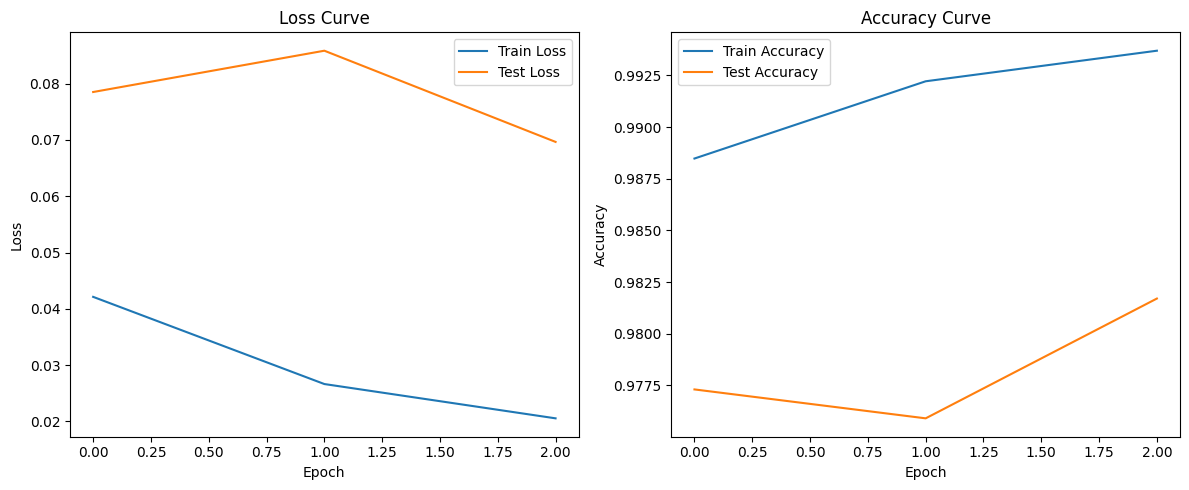

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

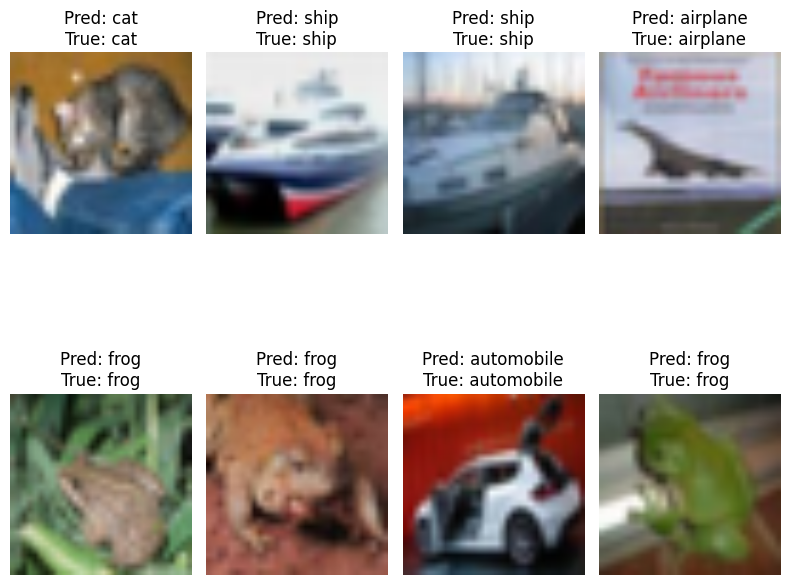

In [ ]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return img_tensor * std + mean

model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images).logits
    preds = outputs.argmax(dim=1)

plt.figure(figsize=(8, 8))
for i in range(8):
    img = denormalize(images[i].cpu()).permute(1,2,0).clamp(0,1)
    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.title(f"Pred: {class_names[preds[i]]}\nTrue: {class_names[labels[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()